In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
search_paths = ["/kaggle/input", "/kaggle/working"]

files_found = []

for base_path in search_paths:
    if os.path.exists(base_path):
        for root, dirs, files in os.walk(base_path):
            for file in files:
                files_found.append(os.path.join(root, file))

print(files_found)

['/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv', '/kaggle/working/.virtual_documents/__notebook_source__.ipynb']


In [3]:
csv_files = [f for f in files_found if f.lower().endswith(".csv")]
zip_files = [f for f in files_found if f.lower().endswith(".zip")]

if csv_files:
    df = pd.read_csv(csv_files[0])
elif zip_files:
    extract_path = "/kaggle/working/creditcard_data"
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_files[0], "r") as z:
        z.extractall(extract_path)

    csv_path = None

    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.lower().endswith(".csv"):
                csv_path = os.path.join(root, file)
                break

    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError("No CSV or ZIP dataset found. Please add the dataset using Add Input.")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print(df.columns.tolist())
print("Missing values:", df.isnull().sum().sum())
print(df.dtypes)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing values: 0
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [6]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
df_small = df.sample(n=30000, random_state=42, stratify=df["Class"])

X = df_small.drop("Class", axis=1)
y = df_small["Class"]

print("Sample shape:", df_small.shape)
print(y.value_counts())

TypeError: NDFrame.sample() got an unexpected keyword argument 'stratify'

In [8]:
from sklearn.model_selection import train_test_split

df_small, _ = train_test_split(
    df,
    train_size=30000,
    random_state=42,
    stratify=df["Class"]
)

X = df_small.drop("Class", axis=1)
y = df_small["Class"]

print("Sample shape:", df_small.shape)
print(y.value_counts())

Sample shape: (30000, 31)
Class
0    29948
1       52
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (24000, 30)
Testing: (6000, 30)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [11]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

print("Logistic Regression completed!")

Logistic Regression completed!


In [12]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

print("Naive Bayes completed!")

Naive Bayes completed!


In [13]:
svm = LinearSVC(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

print("SVM completed!")

SVM completed!


In [14]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_nb = nb.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)

print("Predictions completed!")

Predictions completed!


In [15]:
results = []

models = {
    "Logistic Regression": (lr, y_pred_lr),
    "Naive Bayes": (nb, y_pred_nb),
    "SVM": (svm, y_pred_svm)
}

for name, (model, predictions) in models.items():
    if name == "SVM":
        scores = model.decision_function(X_test_scaled)
    else:
        scores = model.predict_proba(X_test_scaled)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions, zero_division=0),
        recall_score(y_test, predictions, zero_division=0),
        f1_score(y_test, predictions, zero_division=0),
        roc_auc_score(y_test, scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.986,0.0889,0.8,0.1600,0.9647
1,Naive Bayes,0.978,0.0643,0.9,0.1200,0.9575
2,SVM,0.984,0.0784,0.8,0.1429,0.9247


Logistic Regression
[[5908   82]
 [   2    8]]


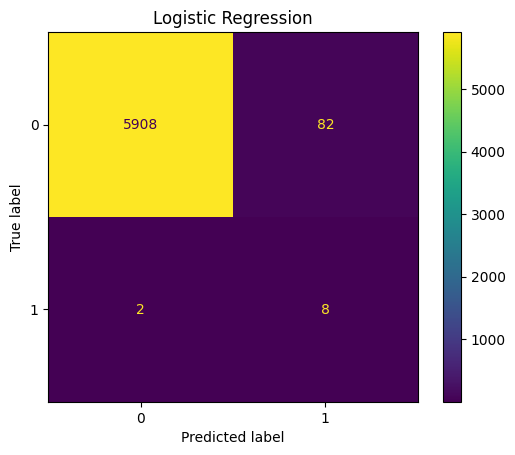

Naive Bayes
[[5859  131]
 [   1    9]]


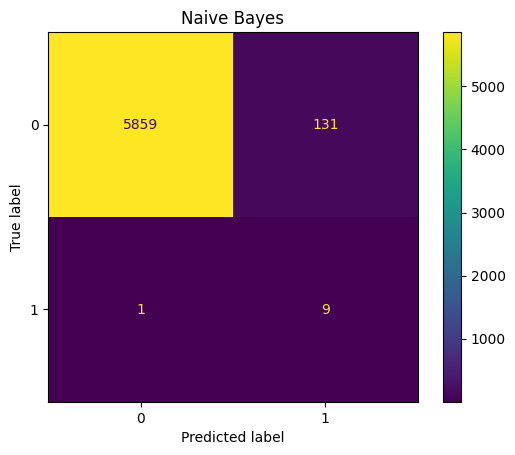

SVM
[[5896   94]
 [   2    8]]


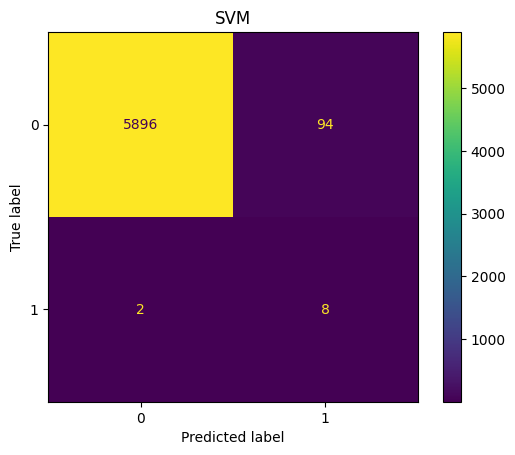

In [16]:
models_pred = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

for name, pred in models_pred.items():
    cm = confusion_matrix(y_test, pred)
    print(name)
    print(cm)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(name)
    plt.show()

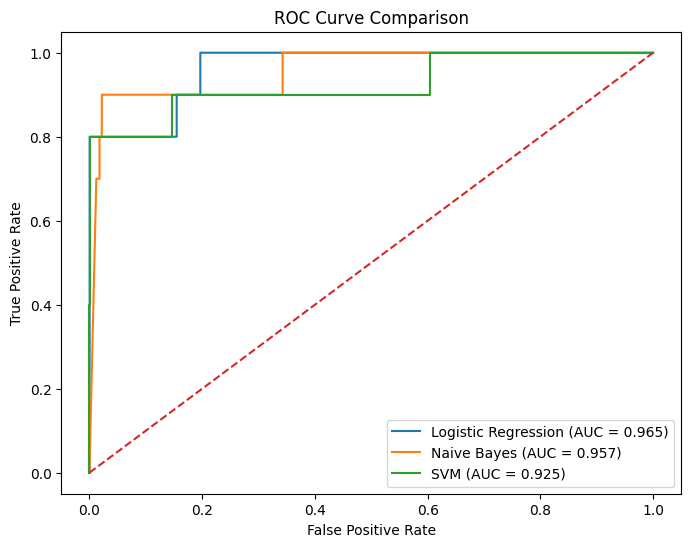

In [17]:
lr_score = lr.predict_proba(X_test_scaled)[:, 1]
nb_score = nb.predict_proba(X_test_scaled)[:, 1]
svm_score = svm.decision_function(X_test_scaled)

scores = {
    "Logistic Regression": lr_score,
    "Naive Bayes": nb_score,
    "SVM": svm_score
}

plt.figure(figsize=(8, 6))

for name, score in scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [18]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.986,0.0889,0.8,0.1600,0.9647
1,Naive Bayes,0.978,0.0643,0.9,0.1200,0.9575
2,SVM,0.984,0.0784,0.8,0.1429,0.9247
